In [ ]:
# Assumes df_merged already computed and saved from previous notebooks (xG-SpatialAware notebook)
import pandas as pd
from pathlib import Path

df_merged = pd.read_parquet(Path("data/derived/df_merged_ad2.parquet"))

df_merged

,index_home,team_name_home,n_pass_home,pass_acc_home,n_prog_pass_home,n_shot_home,n_shot_ot_home,n_shot_box_home,n_keypass_home,n_pressure_home,...,attacking_share_away,recovery_high_away,recovery_mid_away,recovery_low_away,counterpress_won_away,prog_pass_away,prog_carry_away,dangerous_carry_away,switches_away,verticality_away
0,0,Barcelona,917,0.894220,243,25,9,18,16,70,...,1.854167,8,7,20,0,87,21,7,8,0.664569
1,2,Barcelona,628,0.835987,219,11,5,7,8,88,...,1.974719,22,14,23,0,110,29,15,14,0.567752
2,4,Barcelona,701,0.907275,213,30,15,21,22,80,...,2.045139,12,5,13,0,90,24,13,5,0.532781
3,6,Barcelona,783,0.869732,227,12,6,9,9,112,...,1.939873,11,9,14,0,95,28,11,8,0.512752
4,8,Barcelona,765,0.909804,177,21,10,10,16,114,...,1.871795,8,7,15,0,94,21,6,18,0.491921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3459,6918,Barcelona,537,0.798883,171,14,6,9,10,204,...,2.739326,31,4,11,0,114,55,26,15,0.454875
3460,6920,Barcelona,736,0.884511,222,21,9,14,18,96,...,2.296386,23,6,14,0,103,33,12,22,0.472481
3461,6922,Barcelona,581,0.865749,161,11,4,9,8,90,...,2.364641,19,8,7,0,107,46,18,36,0.378024
3462,6924,Barcelona,666,0.881381,219,13,6,7,8,157,...,2.233261,18,5,17,0,103,43,22,12,0.412622


In [2]:
df_xG = pd.read_parquet(Path("data/derived/df_xG.parquet"))
df_xG

,match_id,team_A,xG_A,goals_A,team_B,xG_B,goals_B,xG_diff,goal_diff,abs_xG_diff,xG_sum,result,p_loss_ev,p_draw_ev,p_win_ev,pred_result_ev
0,7430,North Carolina Courage,1.978849,4,Washington Spirit,1.275335,2,0.703514,2,0.703514,3.254184,1,0.174975,0.256791,0.568234,1
1,7443,OL Reign,1.880929,3,Portland Thorns,3.589765,2,-1.708836,1,1.708836,5.470694,1,0.906220,0.067876,0.025904,-1
2,7444,Chicago Red Stars,0.740094,1,North Carolina Courage,2.435871,1,-1.695777,0,1.695777,3.175965,0,0.826759,0.141227,0.032014,-1
3,7445,Utah Royals,0.845233,2,Washington Spirit,0.922957,0,-0.077724,2,0.077724,1.768190,1,0.261429,0.407308,0.331264,0
4,7451,North Carolina Courage,2.033903,1,Washington Spirit,0.820693,0,1.213209,1,1.213209,2.854596,1,0.068447,0.229594,0.701959,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2953,3942819,England,1.141363,2,Netherlands,0.323959,1,0.817403,1,0.817403,1.465322,1,0.140004,0.301839,0.558158,1
2954,3942852,Colombia,1.436105,1,Uruguay,0.955146,0,0.480958,1,0.480958,2.391251,1,0.189004,0.291254,0.519743,1
2955,3943043,England,0.404001,1,Spain,1.238682,2,-0.834681,-1,0.834681,1.642684,-1,0.554352,0.282291,0.163357,-1
2956,3943076,Canada,5.346318,5,Uruguay,4.037971,6,1.308347,-1,1.308347,9.384290,-1,0.061866,0.010686,0.927448,1


In [ ]:
df_xG["match_id"]     = df_xG["match_id"].astype(str)

df_merged = df_merged.merge(
    df_xG[["match_id", "xG_A", "xG_B"]],
    on="match_id",
    how="left"
)

In [4]:
exclude_cols = [
    "goals_home", "opp_goals_home", "goal_diff_team_home",  # target leakage
    "result_bin_home", "result_tri_home", "goals_home", "goals_y_home", "goals_match_sum_home" ,                # target
    "goals_away", "opp_goals_away", "goal_diff_team_away",  # target leakage
    "result_bin_away", "result_tri_away", "goals_away", "goals_y_away", "goals_match_sum_away" , # target
    "xG_sum_home", "xG_sum_away", "xg_per_shot_away", "xg_per_shot_home"
]
feature_cols = [c for c in df_merged.columns if c not in exclude_cols and df_merged[c].dtype != "object"]

X = df_merged[feature_cols].fillna(0)


In [5]:
feature_cols

['index_home',
 'n_pass_home',
 'pass_acc_home',
 'n_prog_pass_home',
 'n_shot_home',
 'n_shot_ot_home',
 'n_shot_box_home',
 'n_keypass_home',
 'n_pressure_home',
 'n_duel_home',
 'n_duel_won_home',
 'n_interception_home',
 'n_interception_won_home',
 'n_foul_committed_home',
 'n_carry_home',
 'n_prog_carry_home',
 'poss_seconds_home',
 'season_id_home',
 'n_pass_ok_home',
 'n_cross_home',
 'n_deep_pass_home',
 'n_shot_blk_home',
 'n_duel_w_home',
 'n_dribble_home',
 'n_dribble_w_home',
 'n_yellow_home',
 'n_red_home',
 'n_freekick_home',
 'n_corner_home',
 'n_touch_home',
 'n_clearance_home',
 'n_offside_home',
 'n_recovery_home',
 'n_pass_final_third_home',
 'n_touch_final_third_home',
 'deep_touches_home',
 'n_box_entry_pass_home',
 'n_box_entry_carry_home',
 'n_danger_pass_home',
 'n_pressure_high_home',
 'n_pressure_regain_home',
 'n_pressure_high_regain_home',
 'n_high_recovery_home',
 'n_counter_home',
 'n_counter_shot_home',
 'duel_win_rate_home',
 'dribble_win_rate_home',
 's

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")


# Target
y_arr = df_merged["result_tri_home"].astype(int).values     # -1,0,1
X_df  = X.copy()                                       # le tue feature
groups = df_merged["match_id"].astype(str).values

# We map y into classes 0,1,2 for OneVsRest+LightGBM
class_map = {-1:0, 0:1,  1:2}
inv_class = {0:-1, 1:0, 2:1}
y_idx = np.array([class_map[v] for v in y_arr])

# OOF probability matrix
oof_proba = np.zeros((len(X_df), 3))
oof_pred_idx = np.zeros(len(X_df), dtype=int)

gkf = GroupKFold(n_splits=5)

for train_idx, test_idx in gkf.split(X_df, y_idx, groups):

    # === TRAIN SET ===
    X_train = X_df.iloc[train_idx].values
    y_train = y_idx[train_idx]

    # === TEST SET ===
    X_test = X_df.iloc[test_idx].values

    # === NORMALIZATION ONLY ON TRAIN ===
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    # === CLASSIFIER ===
    clf = OneVsRestClassifier(
        LGBMClassifier(
            objective="multiclass",
            num_class=3,
            learning_rate=0.05,
            n_estimators=400,
            max_depth=-1,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=42,
            verbosity = -1
        )
    )

    clf.fit(X_train_s, y_train)

    # === OOF PREDICTIONS ===
    proba = clf.predict_proba(X_test_s)
    pred  = clf.predict(X_test_s)

    oof_proba[test_idx]    = proba
    oof_pred_idx[test_idx] = pred

# ===== Classes mapping =====
df_merged["p_loss_mc"] = oof_proba[:, 0]
df_merged["p_draw_mc"] = oof_proba[:, 1]
df_merged["p_win_mc"]  = oof_proba[:, 2]
df_merged["pred_result_mc"] = np.array([inv_class[i] for i in oof_pred_idx])

# ===== REAL OOF METRICS =====
acc = accuracy_score(y_arr, df_merged["pred_result_mc"])
ll  = log_loss(y_idx, oof_proba, labels=[0,1,2])

print(f"OOF accuracy (real):  {acc:.3f}")
print(f"OOF logloss  (real):  {ll:.3f}")

print("\n=== Classification Report (OOF) ===")
print(classification_report(
    y_arr, df_merged["pred_result_mc"],
    labels=[-1,0,1],
    target_names=["Loss (-1)", "Draw (0)", "Win (+1)"],
    digits=3
))


OOF accuracy (real):  0.686
OOF logloss  (real):  0.925

=== Classification Report (OOF) ===
              precision    recall  f1-score   support

   Loss (-1)      0.697     0.764     0.729      1131
    Draw (0)      0.405     0.242     0.303       761
    Win (+1)      0.751     0.846     0.796      1572

    accuracy                          0.686      3464
   macro avg      0.618     0.617     0.609      3464
weighted avg      0.658     0.686     0.666      3464



In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

# If X is a DataFrame I transform it into an array, otherwise I leave it as is
X_arr = X.values if isinstance(X, pd.DataFrame) else X
y_arr = np.asarray(y_arr)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# vector for out-of-fold predictions
y_pred_oof = np.zeros_like(y_arr)

for train_idx, test_idx in cv.split(X_arr, y_arr):
    # fit on train fold
    clf.fit(X_arr[train_idx], y_arr[train_idx])
    # test fold predictions (never seen in training)
    y_pred_oof[test_idx] = clf.predict(X_arr[test_idx])

# real metrics
print(f"Accuracy OOF: {accuracy_score(y_arr, y_pred_oof):.3f}\n")

print(classification_report(
    y_arr,
    y_pred_oof,
    labels=[-1, 0, 1],
    target_names=["Loss (-1)", "Draw (0)", "Win (+1)"],
    digits=3
))

print(confusion_matrix(y_arr, y_pred_oof, labels=[-1, 0, 1]))



Accuracy OOF: 0.681

              precision    recall  f1-score   support

   Loss (-1)      0.681     0.751     0.714      1131
    Draw (0)      0.402     0.231     0.294       761
    Win (+1)      0.750     0.849     0.797      1572

    accuracy                          0.681      3464
   macro avg      0.611     0.610     0.601      3464
weighted avg      0.651     0.681     0.659      3464

[[ 849  150  132]
 [ 273  176  312]
 [ 125  112 1335]]


,feature,importance
132,xG_A,845.333333
133,xG_B,772.266667
49,keypass_rate_home,636.133333
104,keypass_rate_away,602.666667
5,n_shot_ot_home,520.466667
60,n_shot_ot_away,486.133333
85,n_clearance_away,458.733333
30,n_clearance_home,436.533333
92,n_box_entry_carry_away,328.200000
111,attacking_share_home,314.400000


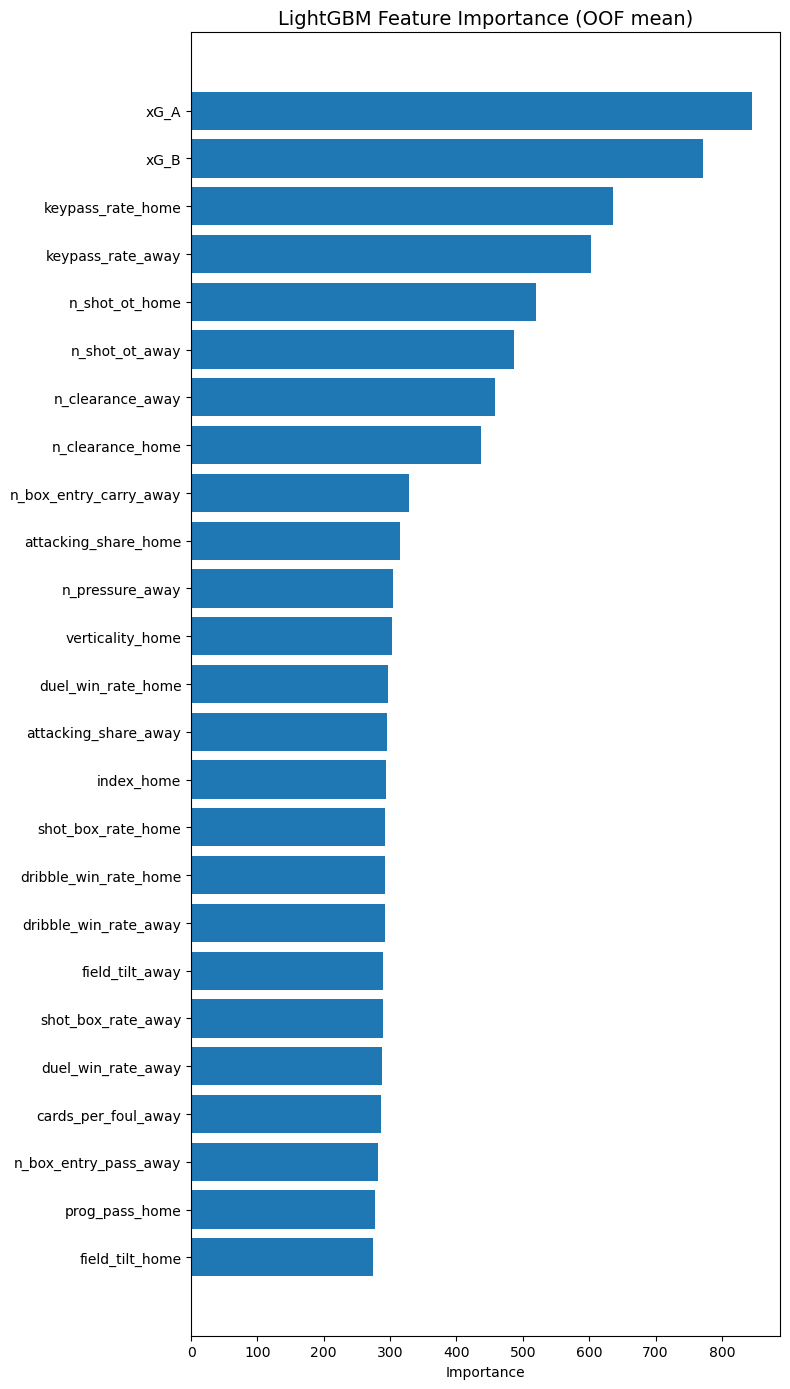

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# ================================
# 1) Setup identical to OOF
# ================================
X_features = X_df.columns.tolist()          
gkf = GroupKFold(n_splits=5)

feature_importances = []

# ================================
# 2) OOF loop to extract importance
# ================================
for train_idx, test_idx in gkf.split(X_df, y_arr, groups):

    X_train = X_df.iloc[train_idx].values
    y_train = y_arr[train_idx]

    # Scaling only on train
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)

    # LightGBM base model
    clf = OneVsRestClassifier(
        LGBMClassifier(
            objective="multiclass",
            num_class=3,
            learning_rate=0.05,
            n_estimators=400,
            max_depth=-1,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        )
    )

    clf.fit(X_train_s, y_train)

    # Retrieve feature importance from each binary model
    fold_imp = np.zeros(len(X_features))

    for estimator in clf.estimators_:   # one per class (OneVsRest)
        fold_imp += estimator.feature_importances_

    # average between the 3 classes
    fold_imp /= len(clf.estimators_)

    feature_importances.append(fold_imp)

# ================================
# 3) Average over all folds
# ================================
fi_mean = np.mean(feature_importances, axis=0)

df_fi = pd.DataFrame({
    "feature": X_features,
    "importance": fi_mean
}).sort_values("importance", ascending=False)

display(df_fi.head(30))

# ================================
# 4) Plot
# ================================
plt.figure(figsize=(8, 14))
plt.barh(df_fi["feature"].head(25)[::-1], df_fi["importance"].head(25)[::-1])
plt.title("LightGBM Feature Importance (OOF mean)", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


shap_values is an ARRAY: (3464, 134, 3)
X shape: (3464, 134)  |  SHAP shape: (3464, 134, 3)


,feature,importance
132,xG_A,0.544532
5,n_shot_ot_home,0.508842
133,xG_B,0.488257
60,n_shot_ot_away,0.398405
49,keypass_rate_home,0.254589
104,keypass_rate_away,0.190070
85,n_clearance_away,0.174606
92,n_box_entry_carry_away,0.171404
30,n_clearance_home,0.169983
37,n_box_entry_carry_home,0.120656



=== SHAP Summary – Loss (-1) ===

=== SHAP Summary – Draw (0) ===

=== SHAP Summary – Win (+1) ===


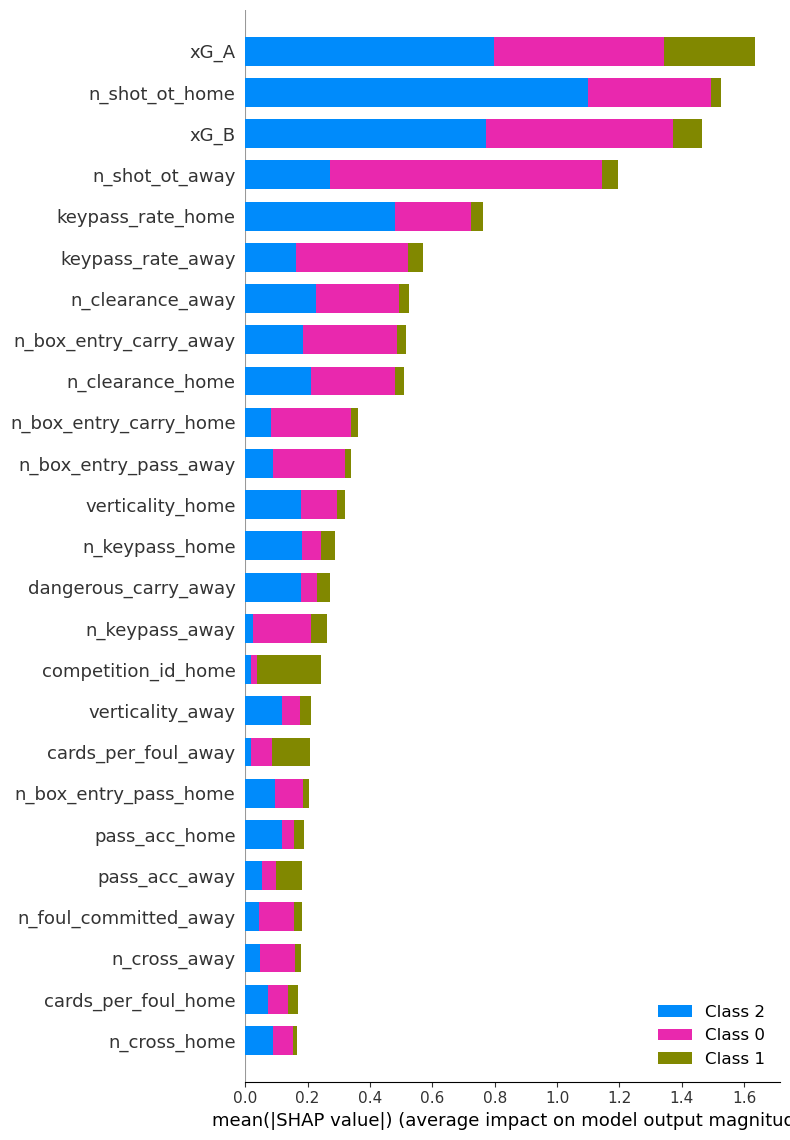

In [ ]:
import shap
import numpy as np
import pandas as pd


# =========================
# 0) Fit final model
# =========================
final_model = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=400,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)
final_model.fit(X, y_idx)  # y_idx in {0,1,2}

# =========================
# 1) SHAP explainer
# =========================
explainer = shap.TreeExplainer(final_model)
sv = explainer.shap_values(X)

# =========================
# 2) Normalize format shap_values ​​-> array (n, p, k)
# =========================
if isinstance(sv, list):
    # list of (n,p) -> (k,n,p) -> (n,p,k)
    print("shap_values is a LIST:")
    print([a.shape for a in sv])
    sv_arr = np.stack(sv, axis=0)          # (k, n, p)
    sv_arr = np.transpose(sv_arr, (1,2,0)) # (n, p, k)
else:
    # already array (n,p,k) or (n,p)
    print("shap_values is an ARRAY:", sv.shape)
    sv_arr = sv
    if sv_arr.ndim == 2:
        # binary case (just to be safe)
        sv_arr = sv_arr[:, :, None]

n, p_shap, k = sv_arr.shape
p_X = X.shape[1]

print(f"X shape: {X.shape}  |  SHAP shape: {sv_arr.shape}")

# If SHAP has an extra feature (bias / expected value), cut it
if p_shap == p_X + 1:
    print("Detected extra bias column in SHAP -> removing last column")
    sv_arr = sv_arr[:, :p_X, :]
    p_shap = p_X

# Final check
assert p_shap == p_X, f"Mismatch features: SHAP has {p_shap}, X has {p_X}"

# =========================
# 3) Overall importance (mean |SHAP|) across all classes
# =========================
mean_abs_shap = np.mean(np.abs(sv_arr), axis=(0, 2))  # (p,)

shap_importance = (
    pd.DataFrame({"feature": X.columns, "importance": mean_abs_shap})
      .sort_values("importance", ascending=False)
)

display(shap_importance.head(30))

# =========================
# 4) Summary plot by class
# =========================
class_names = {0: "Loss (-1)", 1: "Draw (0)", 2: "Win (+1)"}

for c in range(k):
    print(f"\n=== SHAP Summary – {class_names.get(c, c)} ===")
    
    plt.figure(figsize=(10, 20))
    
    
    shap.summary_plot(
        sv_arr[:, :, c],
        X,
        feature_names=X.columns,
        max_display=25,
        show=False
    )
    
    ax = plt.gca()
    ax.tick_params(axis="y", labelsize=20)
    ax.tick_params(axis="x", labelsize=20)
    
    fig = plt.gcf()
    fig.savefig(f"shap_summary_{c}.pdf", bbox_inches="tight")
    plt.close(fig)
    
    plt.tight_layout()

# =========================
# 5) Global bar plot (aggregated)
# =========================
sv_list = [sv_arr[:, :, c] for c in range(k)]
shap.summary_plot(
    sv_list,
    X,
    feature_names=X.columns,
    plot_type="bar",
    max_display=25
)


In [10]:
df_merged

,index_home,team_name_home,n_pass_home,pass_acc_home,n_prog_pass_home,n_shot_home,n_shot_ot_home,n_shot_box_home,n_keypass_home,n_pressure_home,...,prog_carry_away,dangerous_carry_away,switches_away,verticality_away,xG_A,xG_B,p_loss_mc,p_draw_mc,p_win_mc,pred_result_mc
0,0,Barcelona,917,0.894220,243,25,9,18,16,70,...,21,7,8,0.664569,2.881130,0.264819,0.000005,0.001652,0.998343,1
1,2,Barcelona,628,0.835987,219,11,5,7,8,88,...,29,15,14,0.567752,0.826873,0.301977,0.021186,0.283594,0.695220,1
2,4,Barcelona,701,0.907275,213,30,15,21,22,80,...,24,13,5,0.532781,4.314663,1.107642,0.000579,0.001021,0.998400,1
3,6,Barcelona,783,0.869732,227,12,6,9,9,112,...,28,11,8,0.512752,1.326573,0.856557,0.010012,0.002389,0.987599,1
4,8,Barcelona,765,0.909804,177,21,10,10,16,114,...,21,6,18,0.491921,1.724242,1.217625,0.004646,0.000777,0.994577,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3459,6918,Barcelona,537,0.798883,171,14,6,9,10,204,...,55,26,15,0.454875,2.190718,2.831715,0.045044,0.007313,0.947643,1
3460,6920,Barcelona,736,0.884511,222,21,9,14,18,96,...,33,12,22,0.472481,3.494396,2.360884,0.000072,0.003350,0.996578,1
3461,6922,Barcelona,581,0.865749,161,11,4,9,8,90,...,46,18,36,0.378024,1.263421,1.746455,0.353836,0.013376,0.632788,1
3462,6924,Barcelona,666,0.881381,219,13,6,7,8,157,...,43,22,12,0.412622,3.226477,1.142501,0.000333,0.000291,0.999377,1


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau, pearsonr

df = df_merged.copy()

# --------------------------------------------------
# 1) Real points & xPts per team in each match
# --------------------------------------------------
# Real home/away points (3-1-0)
df["home_pts_real"] = np.select(
    [df["goals_home"] > df["goals_away"],
     df["goals_home"] == df["goals_away"]],
    [3, 1], default=0
).astype(int)

df["away_pts_real"] = np.select(
    [df["goals_away"] > df["goals_home"],
     df["goals_away"] == df["goals_home"]],
    [3, 1], default=0
).astype(int)

# Expected points from Combined model probability
# p_win_mc = P(home win), p_draw_mc = P(draw), p_loss_mc = P(home lose)
    
# pred_result_mc in {-1, 0, 1} from home pov
df["home_xpts"] = np.select(
    [df["pred_result_mc"] == 1,
     df["pred_result_mc"] == 0,
     df["pred_result_mc"] == -1],
    [3, 1, 0],
    default=np.nan
).astype(float)

df["away_xpts"] = np.select(
    [df["pred_result_mc"] == 1,
     df["pred_result_mc"] == 0,
     df["pred_result_mc"] == -1],
    [0, 1, 3],
    default=np.nan
).astype(float)

# --------------------------------------------------
#2) Team–match DataFrame (2 rows per match)
#   use competition_name_home / season_name_home as reference
# --------------------------------------------------
home_rows = df[[
    "match_id", "competition_name_home", "season_name_home",
    "team_name_home", "home_pts_real", "home_xpts"
]].rename(columns={
    "competition_name_home": "competition_name",
    "season_name_home": "season_name",
    "team_name_home": "team_name",
    "home_pts_real": "real_points",
    "home_xpts": "xPts_events",
})

away_rows = df[[
    "match_id", "competition_name_home", "season_name_home",
    "team_name_away", "away_pts_real", "away_xpts"
]].rename(columns={
    "competition_name_home": "competition_name",
    "season_name_home": "season_name",
    "team_name_away": "team_name",
    "away_pts_real": "real_points",
    "away_xpts": "xPts_events",
})

df_tm = pd.concat([home_rows, away_rows], ignore_index=True)

# --------------------------------------------------
# 3) Helper functions for rankings and metrics
# --------------------------------------------------
def _league_table(g):
    tab = (g.groupby("team_name", as_index=False)
             .agg(n_matches=("match_id", "nunique"),
                  real_pts=("real_points", "sum"),
                  xpts=("xPts_events", "sum")))
    tab["pts_per_game"]  = tab["real_pts"] / tab["n_matches"]
    tab["xpts_per_game"] = tab["xpts"]     / tab["n_matches"]
    tab["rank_real"] = tab["real_pts"].rank(method="dense", ascending=False).astype(int)
    tab["rank_pred"] = tab["xpts"].rank(method="dense", ascending=False).astype(int)
    tab["rank_diff"] = (tab["rank_real"] - tab["rank_pred"]).astype(int)
    return tab.sort_values("real_pts", ascending=False).reset_index(drop=True)

def _metrics_from_table(tab):
    mae  = np.abs(tab["xpts"] - tab["real_pts"]).mean()
    rmse = np.sqrt(((tab["xpts"] - tab["real_pts"])**2).mean())

    s_r, _ = spearmanr(tab["xpts"], tab["real_pts"])
    k_t, _ = kendalltau(tab["xpts"], tab["real_pts"])
    p_r, _ = pearsonr(tab["xpts"], tab["real_pts"])

    mare = np.abs(tab["rank_real"] - tab["rank_pred"]).mean()

    top4_real = set(tab.nsmallest(4, "rank_real")["team_name"])
    top4_pred = set(tab.nsmallest(4, "rank_pred")["team_name"])
    bot3_real = set(tab.nlargest(3, "rank_real")["team_name"])
    bot3_pred = set(tab.nlargest(3, "rank_pred")["team_name"])

    j_top4 = len(top4_real & top4_pred) / len(top4_real | top4_pred) if (top4_real | top4_pred) else np.nan
    j_bot3 = len(bot3_real & bot3_pred) / len(bot3_real | bot3_pred) if (bot3_real | bot3_pred) else np.nan

    return dict(
        n_teams=len(tab),
        MAE_pts=mae, RMSE_pts=rmse,
        Spearman_rho=s_r, Kendall_tau=k_t, Pearson_r=p_r,
        MARE_rank=mare, Jaccard_top4=j_top4, Jaccard_bottom3=j_bot3
    )

def _match_level_accuracy(g_match):
    """Accuracy tri-class a livello match (una riga per match)."""
    return (g_match["pred_result_mc"] == g_match["result_tri_home"]).mean()

# --------------------------------------------------
# 4) Competition/Season Loops (Home Version)
# --------------------------------------------------
group_cols_match = ["competition_name_home"]
if "season_name_home" in df.columns:
    group_cols_match.append("season_name_home")

summary_rows = []
league_tables = {}

for keys, g_match in df.groupby(group_cols_match):
    keys = (keys,) if not isinstance(keys, tuple) else keys
    comp = keys[0]
    season = keys[1] if len(keys) > 1 else None

    # Team–match correspondents
    mask_team = (df_tm["competition_name"] == comp)
    if season is not None:
        mask_team &= (df_tm["season_name"] == season)
    g_team = df_tm[mask_team]

    # Skip competitions with too few teams (e.g. only the CL final)
    if g_team["team_name"].nunique() < 10:
        continue

    tab = _league_table(g_team)
    league_tables[keys] = tab

    met = _metrics_from_table(tab)
    met["match_acc"] = _match_level_accuracy(g_match)

    row = {
        "competition_name": comp,
    }
    if season is not None:
        row["season_name"] = season
    row.update(met)
    summary_rows.append(row)

summary = (pd.DataFrame(summary_rows)
             .sort_values(["Spearman_rho", "Pearson_r"], ascending=False)
             .reset_index(drop=True))

summary.head(20)


,competition_name,season_name,n_teams,MAE_pts,RMSE_pts,Spearman_rho,Kendall_tau,Pearson_r,MARE_rank,Jaccard_top4,Jaccard_bottom3,match_acc
0,La Liga,2016/2017,20,0.750000,1.857418,0.954484,0.894339,0.997344,0.850000,0.600000,1.0,0.882353
1,FA Women's Super League,2018/2019,11,3.636364,4.972652,0.938499,0.844072,0.955936,0.818182,1.000000,0.5,0.768519
2,UEFA Euro,2020,24,1.708333,2.474874,0.915992,0.804315,0.875623,2.458333,0.600000,0.2,0.705882
3,FA Women's Super League,2020/2021,12,3.583333,4.627814,0.915200,0.803175,0.971877,1.083333,1.000000,0.5,0.709924
4,UEFA Euro,2024,24,1.208333,1.670828,0.910770,0.824951,0.940529,0.916667,1.000000,0.2,0.686275
5,1. Bundesliga,2023/2024,18,0.444444,1.105542,0.905278,0.884149,0.998683,0.111111,0.600000,0.5,0.823529
6,Serie A,2015/2016,20,6.300000,7.375636,0.882863,0.730669,0.904641,1.700000,0.600000,0.5,0.652632
7,FA Women's Super League,2019/2020,12,3.916667,4.609772,0.863163,0.677003,0.921122,1.500000,1.000000,0.5,0.724138
8,Women's World Cup,2019,24,2.000000,2.857738,0.856088,0.747733,0.883391,1.208333,1.000000,0.2,0.750000
9,La Liga,2008/2009,19,0.736842,1.450953,0.838903,0.749927,0.996468,1.105263,0.333333,0.2,0.774194


In [ ]:
import numpy as np
import pandas as pd

# ---------- helper: builds ranking for a group ----------
def _league_table(g: pd.DataFrame) -> pd.DataFrame:
    tab = (g.groupby("team_name", as_index=False)
             .agg(n_matches=("match_id","nunique"),
                  real_pts=("real_points","sum"),
                  xpts=("xPts_events","sum")))
    tab["pts_per_game"]  = tab["real_pts"] / tab["n_matches"]
    tab["xpts_per_game"] = tab["xpts"]     / tab["n_matches"]
    tab["rank_real"] = tab["real_pts"].rank(method="dense", ascending=False).astype(int)
    tab["rank_pred"] = tab["xpts"].rank(method="dense", ascending=False).astype(int)
    tab["rank_diff"] = (tab["rank_real"] - tab["rank_pred"]).astype(int)
    return tab.sort_values(["real_pts","xpts"], ascending=False).reset_index(drop=True)

# ---------- If you don't already have league_tables, build it ----------
def build_league_tables(df: pd.DataFrame):
    group_cols = ["competition_name"] + (["season_name"] if "season_name" in df.columns else [])
    lt = {}
    for keys, g in df.groupby(group_cols):
        keys = (keys,) if not isinstance(keys, tuple) else keys
        lt[keys] = _league_table(g)
    return lt

if "league_tables" not in globals():
    df = df_merged.copy()
    # safety: creates columns if missing
    if "real_points" not in df.columns:
        df["real_points"] = np.select(
            [df["goals"] > df["opp_goals"], df["goals"] == df["opp_goals"]],
            [3, 1], default=0
        ).astype(int)
    if "xPts_events" not in df.columns:
        df["xPts_events"] = 3*df["p_win_mc"] + 1*df["p_draw_mc"]
    league_tables = build_league_tables(df)

# ---------- Visualization ----------
def show_league_table(competition: str, season: str | None = None,
                      top: int | None = None, sort_by: str = "real_pts"):
    """
    Display the standings for (competition[, season]).
    - competition: e.g., "Serie A"
    - season: e.g., "2015/2016" (if available); otherwise, leave None
    - top: show only the top N rows (None = all)
    - sort_by: 'real_pts' (default) or 'xpts' to sort by the predicted metric
    """
    # find the correct key (with or without season)
    keys = (competition,) if season is None else (competition, season)
    if keys not in league_tables:
        # If the user has passed a season but the keys do not include it, try without
        if season is not None and (competition,) in league_tables:
            print("⚠️ No saved seasons: I only use competition.")
            keys = (competition,)
        else:
            raise KeyError(f"Ranking not found for key: {keys}")

    tab = league_tables[keys].copy()
    if sort_by in tab.columns:
        tab = tab.sort_values(sort_by, ascending=False).reset_index(drop=True)

    cols = ["team_name","n_matches","real_pts","xpts",
            "pts_per_game","xpts_per_game","rank_real","rank_pred","rank_diff"]
    tab = tab[cols]
    if top is not None:
        tab = tab.head(top)

    # formattazione
    display(
        tab.style
           .format({"pts_per_game":"{:.3f}","xpts_per_game":"{:.3f}"})
           .bar(subset=["real_pts","xpts"], color="#cfe8ff")
           .background_gradient(subset=["rank_diff"], cmap="RdYlGn_r")
           .set_caption(f"League Table — {competition}" + (f" ({season})" if season else ""))
    )

# --------- EXAMPLES ----------
# competition only (if you don't have a season)
#show_league_table("Serie A", top=20)

# competition + season (if 'season_name' is present in the keys)
show_league_table("1. Bundesliga", season="2015/2016", top=10)

# sort by expected metric points
# show_league_table("La Liga", season="2014/2015", sort_by="xpts")

,team_name,n_matches,real_pts,xpts,pts_per_game,xpts_per_game,rank_real,rank_pred,rank_diff
0,Bayern Munich,34,88,93.000000,2.588,2.735,1,1,0
1,Borussia Dortmund,34,78,82.000000,2.294,2.412,2,2,0
2,Bayer Leverkusen,34,60,60.000000,1.765,1.765,3,5,-2
3,Borussia Mönchengladbach,34,55,66.000000,1.618,1.941,4,3,1
4,Schalke 04,34,52,49.000000,1.529,1.441,5,7,-2
5,Hertha Berlin,34,50,51.000000,1.471,1.500,6,6,0
6,FSV Mainz 05,34,50,61.000000,1.471,1.794,6,4,2
7,Wolfsburg,34,45,39.000000,1.324,1.147,7,12,-5
8,FC Köln,34,43,43.000000,1.265,1.265,8,10,-2
9,Hamburger SV,34,41,32.000000,1.206,0.941,9,15,-6


In [ ]:
# Top 5 leagues to select
top5 = ["Premier League", "Serie A", "1. Bundesliga", "Ligue 1", "La Liga"]

# Summary filter
summary_top5 = summary[summary["competition_name"].isin(top5)].copy()

# Rank by Spearman or Pearson
summary_top5 = summary_top5.sort_values("Spearman_rho", ascending=False)

# Show
summary_top5.style.format({
    "MAE_pts": "{:.2f}",
    "RMSE_pts": "{:.2f}",
    "Spearman_rho": "{:.3f}",
    "Kendall_tau": "{:.3f}",
    "Pearson_r": "{:.3f}",
    "MARE_rank": "{:.2f}",
    "Jaccard_top4": "{:.2f}",
    "Jaccard_bottom3": "{:.2f}",
    "match_acc": "{:.3f}"
}).set_caption("Top-5 European Leagues — Event-based Expected Points vs Real Points")


,competition_name,season_name,n_teams,MAE_pts,RMSE_pts,Spearman_rho,Kendall_tau,Pearson_r,MARE_rank,Jaccard_top4,Jaccard_bottom3,match_acc
0,La Liga,2016/2017,20,0.75,1.86,0.954,0.894,0.997,0.85,0.60,1.00,0.882
5,1. Bundesliga,2023/2024,18,0.44,1.11,0.905,0.884,0.999,0.11,0.60,0.50,0.824
6,Serie A,2015/2016,20,6.30,7.38,0.883,0.731,0.905,1.70,0.60,0.50,0.653
9,La Liga,2008/2009,19,0.74,1.45,0.839,0.750,0.996,1.11,0.33,0.20,0.774
11,La Liga,2018/2019,20,0.95,2.56,0.824,0.755,0.999,0.70,0.60,0.00,0.735
14,Premier League,2015/2016,20,5.85,7.77,0.813,0.688,0.885,2.90,0.60,0.50,0.626
15,1. Bundesliga,2015/2016,18,5.22,6.24,0.808,0.633,0.946,2.06,0.60,0.50,0.683
16,La Liga,2014/2015,20,0.70,1.41,0.806,0.760,0.999,0.35,1.00,0.20,0.842
17,La Liga,2015/2016,20,5.90,7.64,0.780,0.651,0.928,1.85,1.00,0.50,0.674
18,Ligue 1,2021/2022,18,1.17,3.15,0.780,0.732,0.999,1.28,1.00,0.00,0.577


In [15]:
df_metrics_xg = pd.read_parquet(Path("data/derived/metrics_xG_df.parquet"))

df_metrics_event = summary.copy()

In [16]:
df_metrics_xg = df_metrics_xg.rename(columns={"competition": "competition_name"})


In [17]:
# Assumo che tu abbia già:
# - df_metrics_event  → metriche della nuova metrica (event-based)
# - df_metrics_xg     → metriche degli xG (quelle fatte giorni fa)

df_compare = (
    df_metrics_event.merge(
        df_metrics_xg,
        on=["competition_name"], 
        suffixes=("_event", "_xg")
    )
)

# Ordina per Spearman_event
df_compare = df_compare.sort_values("Spearman_rho_event", ascending=False)

df_compare.head(50)


,competition_name,season_name,n_teams,MAE_pts_event,RMSE_pts_event,Spearman_rho_event,Kendall_tau_event,Pearson_r_event,MARE_rank,Jaccard_top4,Jaccard_bottom3,match_acc,MAE_pts_xg,RMSE_pts_xg,Spearman_rho_xg,Kendall_tau_xg,Pearson_r_xg
0,La Liga,2016/2017,20,0.750000,1.857418,0.954484,0.894339,0.997344,0.850000,0.600000,1.0,0.882353,4.585366,7.251577,0.941433,0.841496,0.999406
1,UEFA Euro,2020,24,1.708333,2.474874,0.915992,0.804315,0.875623,2.458333,0.600000,0.2,0.705882,3.448276,4.697762,0.820910,0.646207,0.818809
2,UEFA Euro,2024,24,1.208333,1.670828,0.910770,0.824951,0.940529,0.916667,1.000000,0.2,0.686275,3.448276,4.697762,0.820910,0.646207,0.818809
3,1. Bundesliga,2023/2024,18,0.444444,1.105542,0.905278,0.884149,0.998683,0.111111,0.600000,0.5,0.823529,7.000000,9.350657,0.805260,0.680184,0.957552
4,Serie A,2015/2016,20,6.300000,7.375636,0.882863,0.730669,0.904641,1.700000,0.600000,0.5,0.652632,7.400000,9.914636,0.712887,0.545486,0.839190
5,La Liga,2008/2009,19,0.736842,1.450953,0.838903,0.749927,0.996468,1.105263,0.333333,0.2,0.774194,4.585366,7.251577,0.941433,0.841496,0.999406
6,La Liga,2018/2019,20,0.950000,2.559297,0.824340,0.754539,0.999332,0.700000,0.600000,0.0,0.735294,4.585366,7.251577,0.941433,0.841496,0.999406
7,Premier League,2015/2016,20,5.850000,7.774960,0.812621,0.688410,0.884900,2.900000,0.600000,0.5,0.626316,4.896552,6.480741,0.960558,0.861904,0.983846
8,1. Bundesliga,2015/2016,18,5.222222,6.244998,0.807873,0.633347,0.946242,2.055556,0.600000,0.5,0.683007,7.000000,9.350657,0.805260,0.680184,0.957552
9,La Liga,2014/2015,20,0.700000,1.414214,0.806373,0.760020,0.999223,0.350000,1.000000,0.2,0.842105,4.585366,7.251577,0.941433,0.841496,0.999406


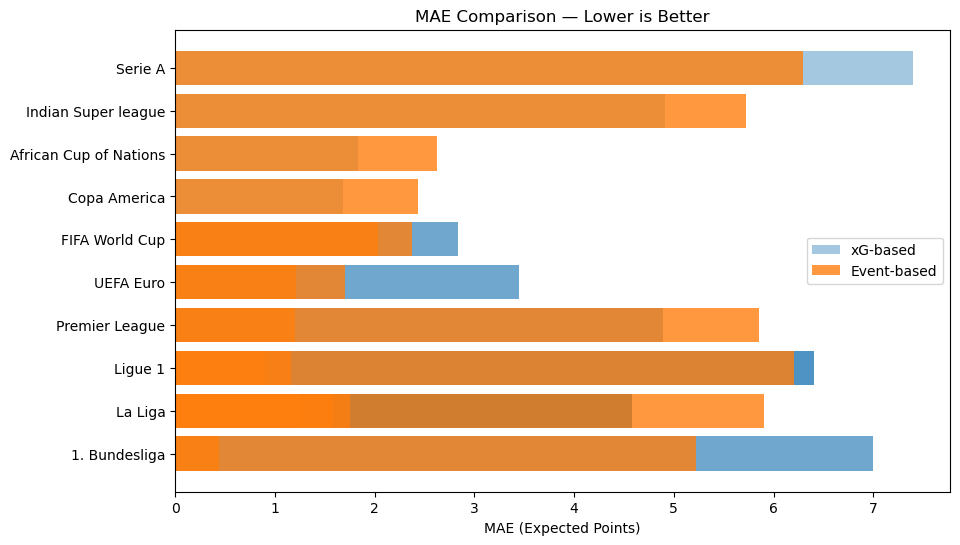

In [18]:
import matplotlib.pyplot as plt
df_tmp = df_compare.sort_values("MAE_pts_event")

plt.figure(figsize=(10,6))
plt.barh(df_tmp["competition_name"], df_tmp["MAE_pts_xg"], alpha=0.4, label="xG-based")
plt.barh(df_tmp["competition_name"], df_tmp["MAE_pts_event"], alpha=0.8, label="Event-based")
plt.xlabel("MAE (Expected Points)")
plt.title("MAE Comparison — Lower is Better")
plt.legend()
plt.show()


In [19]:
df_xG = pd.read_parquet(Path("data/derived/df_xG.parquet"))

In [20]:
df_xG.columns

Index(['match_id', 'team_A', 'xG_A', 'goals_A', 'team_B', 'xG_B', 'goals_B',
       'xG_diff', 'goal_diff', 'abs_xG_diff', 'xG_sum', 'result', 'p_loss_ev',
       'p_draw_ev', 'p_win_ev', 'pred_result_ev'],
      dtype='object')

In [21]:
df_xG = df_xG.rename(columns={"p_loss_ev": "p_loss", "p_draw_ev": "p_draw", "p_win_ev": "p_win"})

In [22]:
df_tm.columns

Index(['match_id', 'competition_name', 'season_name', 'team_name',
       'real_points', 'xPts_events'],
      dtype='object')

In [23]:
import numpy as np
import pandas as pd

# Copie
dx = df_xG.copy()
de = df_tm.copy()

# Allineiamo i tipi di match_id
dx["match_id"] = dx["match_id"].astype(str)
de["match_id"] = de["match_id"].astype(str)

# =====================================================
# 1) Espando df_xG a livello TEAM (2 righe per match)
# =====================================================

rows = []
for r in dx.itertuples():
    # Punti reali
    if r.goals_A > r.goals_B:
        pts_A, pts_B = 3, 0
    elif r.goals_A < r.goals_B:
        pts_A, pts_B = 0, 3
    else:
        pts_A, pts_B = 1, 1

    # Expected points da xG
    ep_A = np.select([
        r.pred_result_ev == 1,
        r.pred_result_ev == 0,
        r.pred_result_ev == -1],
        [3, 1, 0],
        default=np.nan
    ).astype(float)

    ep_B = np.select(
        [r.pred_result_ev == 1,
        r.pred_result_ev == 0,
        r.pred_result_ev == -1],
        [0, 1, 3],
        default=np.nan
    ).astype(float)

    rows.append({
        "match_id": r.match_id,
        "team_name": r.team_A,
        "real_points": pts_A,
        "EP_xg": ep_A,
        "side": "A",
    })
    rows.append({
        "match_id": r.match_id,
        "team_name": r.team_B,
        "real_points": pts_B,
        "EP_xg": ep_B,
        "side": "B",
    })

df_xg_team = pd.DataFrame(rows)

print("Righe df_xg_team:", len(df_xg_team))
print(df_xg_team.head())

# =====================================================
# 2) Prendo da df_merged gli xPts_events per team×match
# =====================================================

df_ev_team = (
    de[["match_id", "team_name", "xPts_events", "competition_name", "season_name"]]
    .drop_duplicates(["match_id", "team_name"])
    .copy()
)

print("Righe df_ev_team:", len(df_ev_team))
print(df_ev_team.head())

# =====================================================
# 3) Merge: xG-team-level ↔ event-team-level
# =====================================================

df_team = df_xg_team.merge(
    df_ev_team,
    on=["match_id", "team_name"],
    how="inner",  # consideriamo solo i match presenti in entrambi
)

print("Righe dopo merge:", len(df_team))

# =====================================================
# 4) Errori per squadra-partita
# =====================================================

df_team["err_xg"]    = (df_team["EP_xg"]       - df_team["real_points"]).abs()
df_team["err_event"] = (df_team["xPts_events"] - df_team["real_points"]).abs()

MAE_xg_team    = df_team["err_xg"].mean()
MAE_event_team = df_team["err_event"].mean()

RMSE_xg_team    = np.sqrt(((df_team["EP_xg"]       - df_team["real_points"])**2).mean())
RMSE_event_team = np.sqrt(((df_team["xPts_events"] - df_team["real_points"])**2).mean())

print("\n=== ERRORE PER SQUADRA-PARTITA ===")
print(f"MAE xG:          {MAE_xg_team:.3f}")
print(f"MAE Event-based: {MAE_event_team:.3f}")
print(f"RMSE xG:         {RMSE_xg_team:.3f}")
print(f"RMSE Event:      {RMSE_event_team:.3f}")

df_team.head(20)


Righe df_xg_team: 5916
  match_id               team_name  real_points EP_xg side
0     7430  North Carolina Courage            3   3.0    A
1     7430       Washington Spirit            0   0.0    B
2     7443                OL Reign            3   0.0    A
3     7443         Portland Thorns            0   3.0    B
4     7444       Chicago Red Stars            1   0.0    A
Righe df_ev_team: 6928
  match_id  team_name  xPts_events competition_name season_name
0    15946  Barcelona          3.0          La Liga   2018/2019
1    15956  Barcelona          3.0          La Liga   2018/2019
2    15973  Barcelona          3.0          La Liga   2018/2019
3    15978  Barcelona          3.0          La Liga   2018/2019
4    15986  Barcelona          3.0          La Liga   2018/2019
Righe dopo merge: 5916

=== ERRORE PER SQUADRA-PARTITA ===
MAE xG:          0.725
MAE Event-based: 0.581
RMSE xG:         1.283
RMSE Event:      1.104


,match_id,team_name,real_points,EP_xg,side,xPts_events,competition_name,season_name,err_xg,err_event
0,7430,North Carolina Courage,3,3.0,A,3.0,NWSL,2018,0.0,0.0
1,7430,Washington Spirit,0,0.0,B,0.0,NWSL,2018,0.0,0.0
2,7443,OL Reign,3,0.0,A,3.0,NWSL,2018,3.0,0.0
3,7443,Portland Thorns,0,3.0,B,0.0,NWSL,2018,3.0,0.0
4,7444,Chicago Red Stars,1,0.0,A,0.0,NWSL,2018,1.0,1.0
5,7444,North Carolina Courage,1,3.0,B,3.0,NWSL,2018,2.0,2.0
6,7445,Utah Royals,3,1.0,A,3.0,NWSL,2018,2.0,0.0
7,7445,Washington Spirit,0,1.0,B,0.0,NWSL,2018,1.0,0.0
8,7451,North Carolina Courage,3,3.0,A,3.0,NWSL,2018,0.0,0.0
9,7451,Washington Spirit,0,0.0,B,0.0,NWSL,2018,0.0,0.0


=== GLOBAL ERRORS ===


,label,MAE_xG,MAE_Event,RMSE_xG,RMSE_Event
0,GLOBAL,0.725152,0.581136,1.283246,1.103961



=== ERRORS BY COMPETITION ===


,label,MAE_xG,MAE_Event,RMSE_xG,RMSE_Event
5,FIFA U20 World Cup,0.000000,0.000000,0.000000,0.000000
9,Liga Profesional,0.000000,0.000000,0.000000,0.000000
13,North American League,0.000000,0.000000,0.000000,0.000000
11,Major League Soccer,0.250000,0.250000,0.645497,0.645497
2,Champions League,0.833333,0.333333,1.433721,1.000000
8,La Liga,0.572664,0.477509,1.130218,0.992475
4,Copa del Rey,1.000000,0.500000,1.732051,0.912871
12,NWSL,0.583333,0.500000,1.142609,0.971825
0,1. Bundesliga,0.719118,0.538235,1.291943,1.080577
10,Ligue 1,0.731034,0.606897,1.263092,1.101723


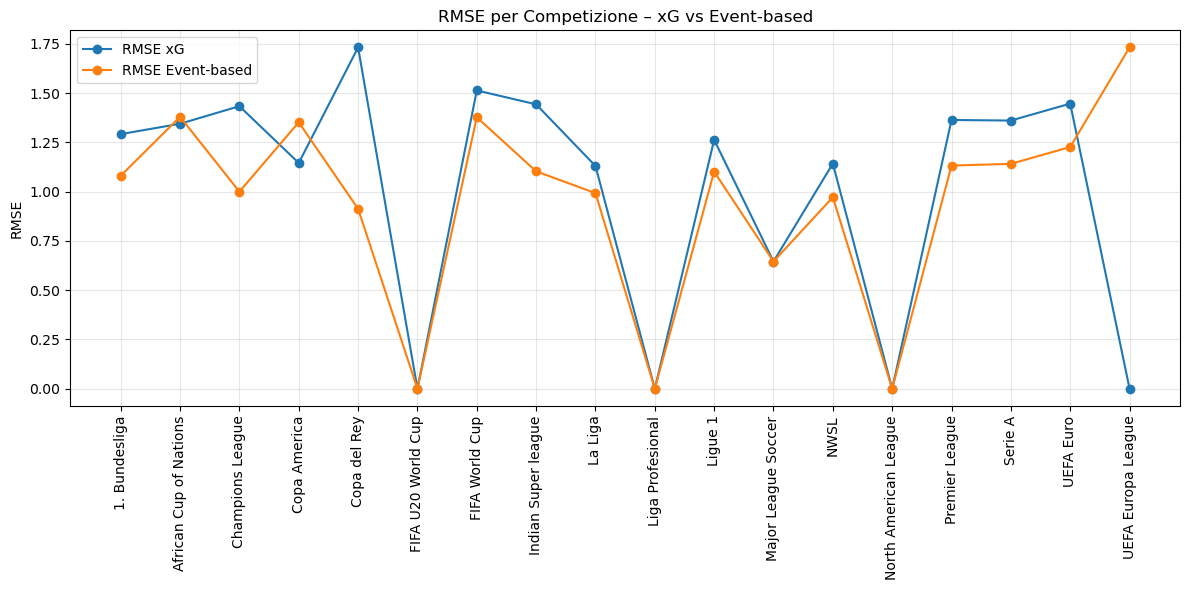

In [24]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np

# ===============================
# Funzione per calcolare MAE/RMSE
# ===============================
def compute_errors(df, label="ALL"):
    mae_xg    = mean_absolute_error(df["real_points"], df["EP_xg"])
    mae_event = mean_absolute_error(df["real_points"], df["xPts_events"])

    rmse_xg    = root_mean_squared_error(df["real_points"], df["EP_xg"])
    rmse_event = root_mean_squared_error(df["real_points"], df["xPts_events"])

    return pd.DataFrame({
        "label": [label],
        "MAE_xG": [mae_xg],
        "MAE_Event": [mae_event],
        "RMSE_xG": [rmse_xg],
        "RMSE_Event": [rmse_event]
    })

# ================================
# 1️⃣ ERRORI GLOBALI (tutto il dataset)
# ================================
table_global = compute_errors(df_team, "GLOBAL")

# ================================
# 2️⃣ ERRORI PER COMPETIZIONE
# ================================
rows_comp = []

for comp, g in df_team.groupby("competition_name"):
    rows_comp.append(compute_errors(g, comp))

table_comp = pd.concat(rows_comp, ignore_index=True)

# ================================
# 3️⃣ ERRORI PER STAGIONE (opzionale)
# ================================
# rows_season = []
# for season, g in df_team.groupby("season_id"):
#     rows_season.append(compute_errors(g, f"Season {season}"))
# table_season = pd.concat(rows_season, ignore_index=True)

# ================================
# Mostra i risultati
# ================================
print("=== GLOBAL ERRORS ===")
display(table_global)

print("\n=== ERRORS BY COMPETITION ===")
display(table_comp.sort_values("MAE_Event"))

# print("\n=== ERRORS BY SEASON ===")
# display(table_season.sort_values("MAE_Event"))

# ================================
# (OPZIONALE) Grafico comparativo
# ================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(table_comp["label"], table_comp["RMSE_xG"], marker="o", label="RMSE xG")
plt.plot(table_comp["label"], table_comp["RMSE_Event"], marker="o", label="RMSE Event-based")
plt.xticks(rotation=90)
plt.ylabel("RMSE")
plt.title("RMSE per Competizione – xG vs Event-based")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
df_team_event = pd.read_parquet(Path("data/derived/df_team_event.parquet"))

df_team_event = df_team_event.rename(columns={'xPts_events': 'xPts_events_eb'})

df_team = df_team.merge(
    df_team_event[["match_id","competition_name","team_name","xPts_events_eb"]],
    on=["match_id", "competition_name", "team_name"], how="left"
)

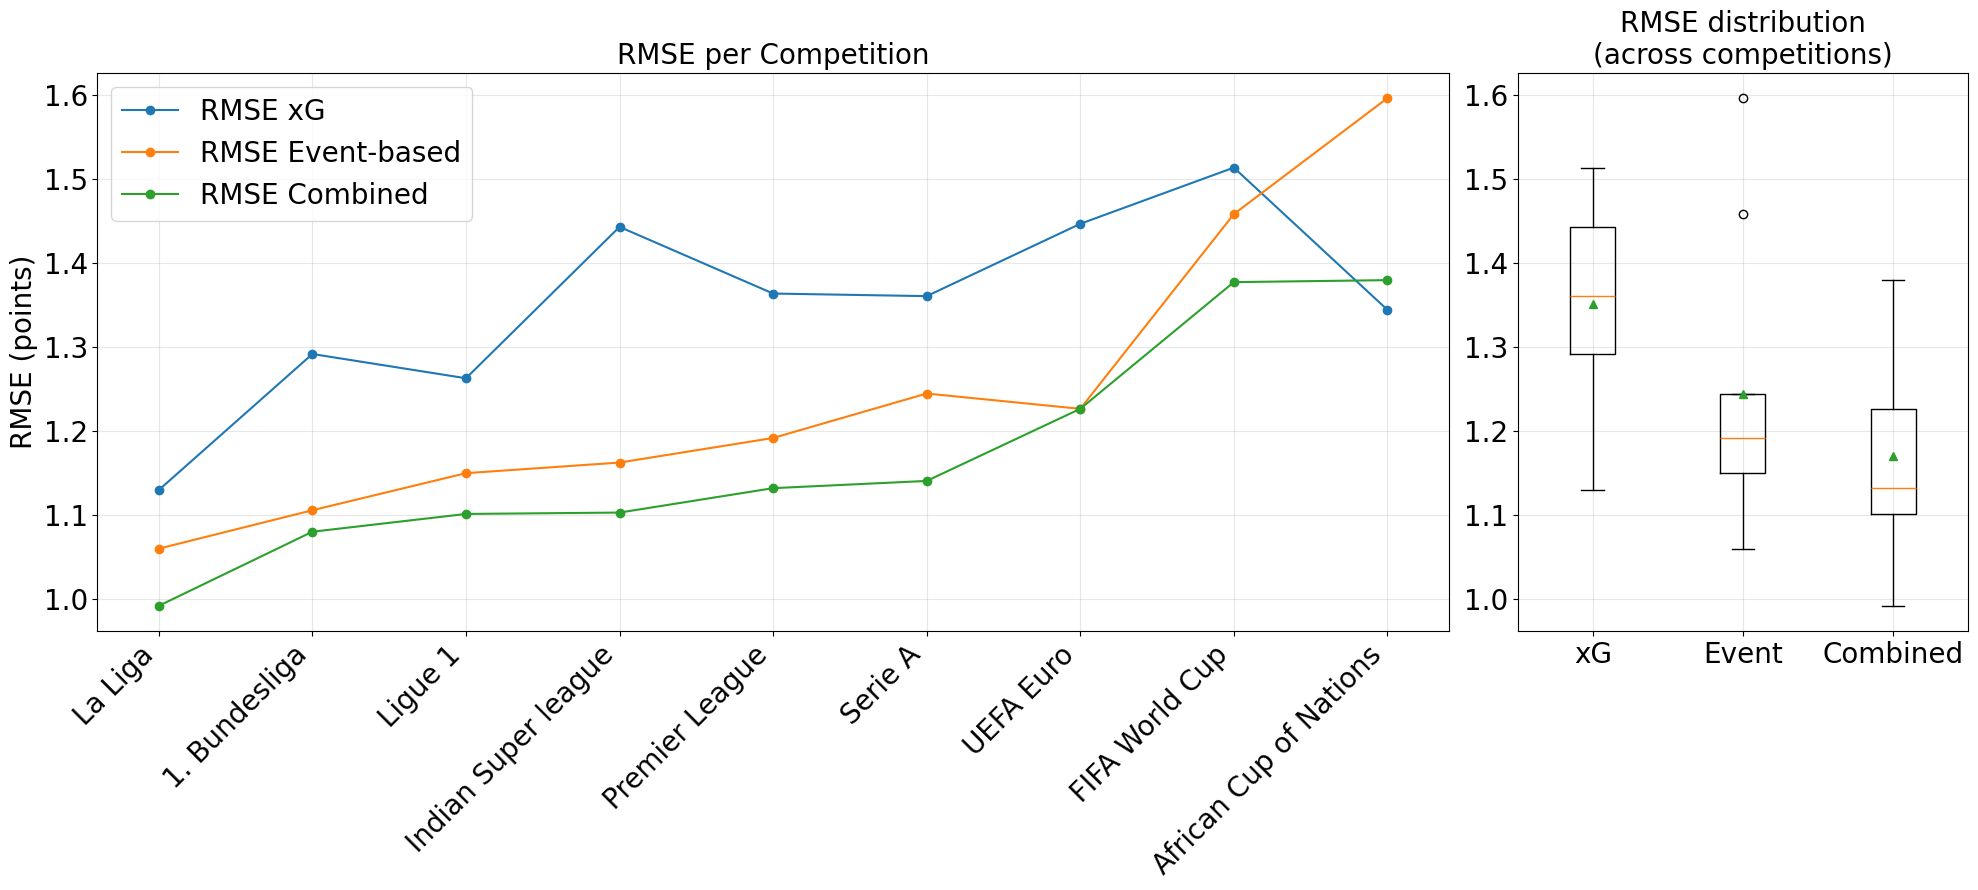

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

# ===============================
# Calcolo RMSE per competizione
# ===============================
rows = []
min_matches = 50

for comp, g in df_team.groupby("competition_name"):
    if g["match_id"].nunique() < min_matches:
        continue
    rows.append({
        "competition": comp,
        "RMSE_xG": root_mean_squared_error(g["real_points"], g["EP_xg"]),
        "RMSE_Event": root_mean_squared_error(g["real_points"], g["xPts_events_eb"]),
        "RMSE_Combined": root_mean_squared_error(g["real_points"], g["xPts_events"])
    })

rmse_comp = pd.DataFrame(rows).sort_values("RMSE_Combined")

# ===============================
# Plot: linee (sx) + boxplot (dx)
# ===============================
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 9),
    gridspec_kw={"width_ratios": [3, 1]}
)

# --- Sinistra: andamento per competizione ---
ax1.plot(rmse_comp["competition"], rmse_comp["RMSE_xG"], marker="o", label="RMSE xG")
ax1.plot(rmse_comp["competition"], rmse_comp["RMSE_Event"], marker="o", label="RMSE Event-based")
ax1.plot(rmse_comp["competition"], rmse_comp["RMSE_Combined"], marker="o", label="RMSE Combined")

ax1.set_xticks(range(len(rmse_comp)))
ax1.set_xticklabels(rmse_comp["competition"], rotation=45, ha="right", fontsize=20)
ax1.set_ylabel("RMSE (points)", fontsize=20)
ax1.tick_params(axis="y", labelsize=20)
ax1.set_title("RMSE per Competition", fontsize=20)
ax1.legend(fontsize=20)
ax1.grid(alpha=0.3)

# --- Destra: boxplot comparativo dei 3 modelli ---
data = [
    rmse_comp["RMSE_xG"].values,
    rmse_comp["RMSE_Event"].values,
    rmse_comp["RMSE_Combined"].values
]
ax2.boxplot(data, labels=["xG", "Event", "Combined"], showmeans=True)
ax2.set_title("RMSE distribution\n(across competitions)", fontsize=20)
ax2.tick_params(axis="x", labelsize=20)
ax2.tick_params(axis="y", labelsize=20)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig("rmse_competitions50.pdf", format="pdf", bbox_inches="tight")
plt.show()


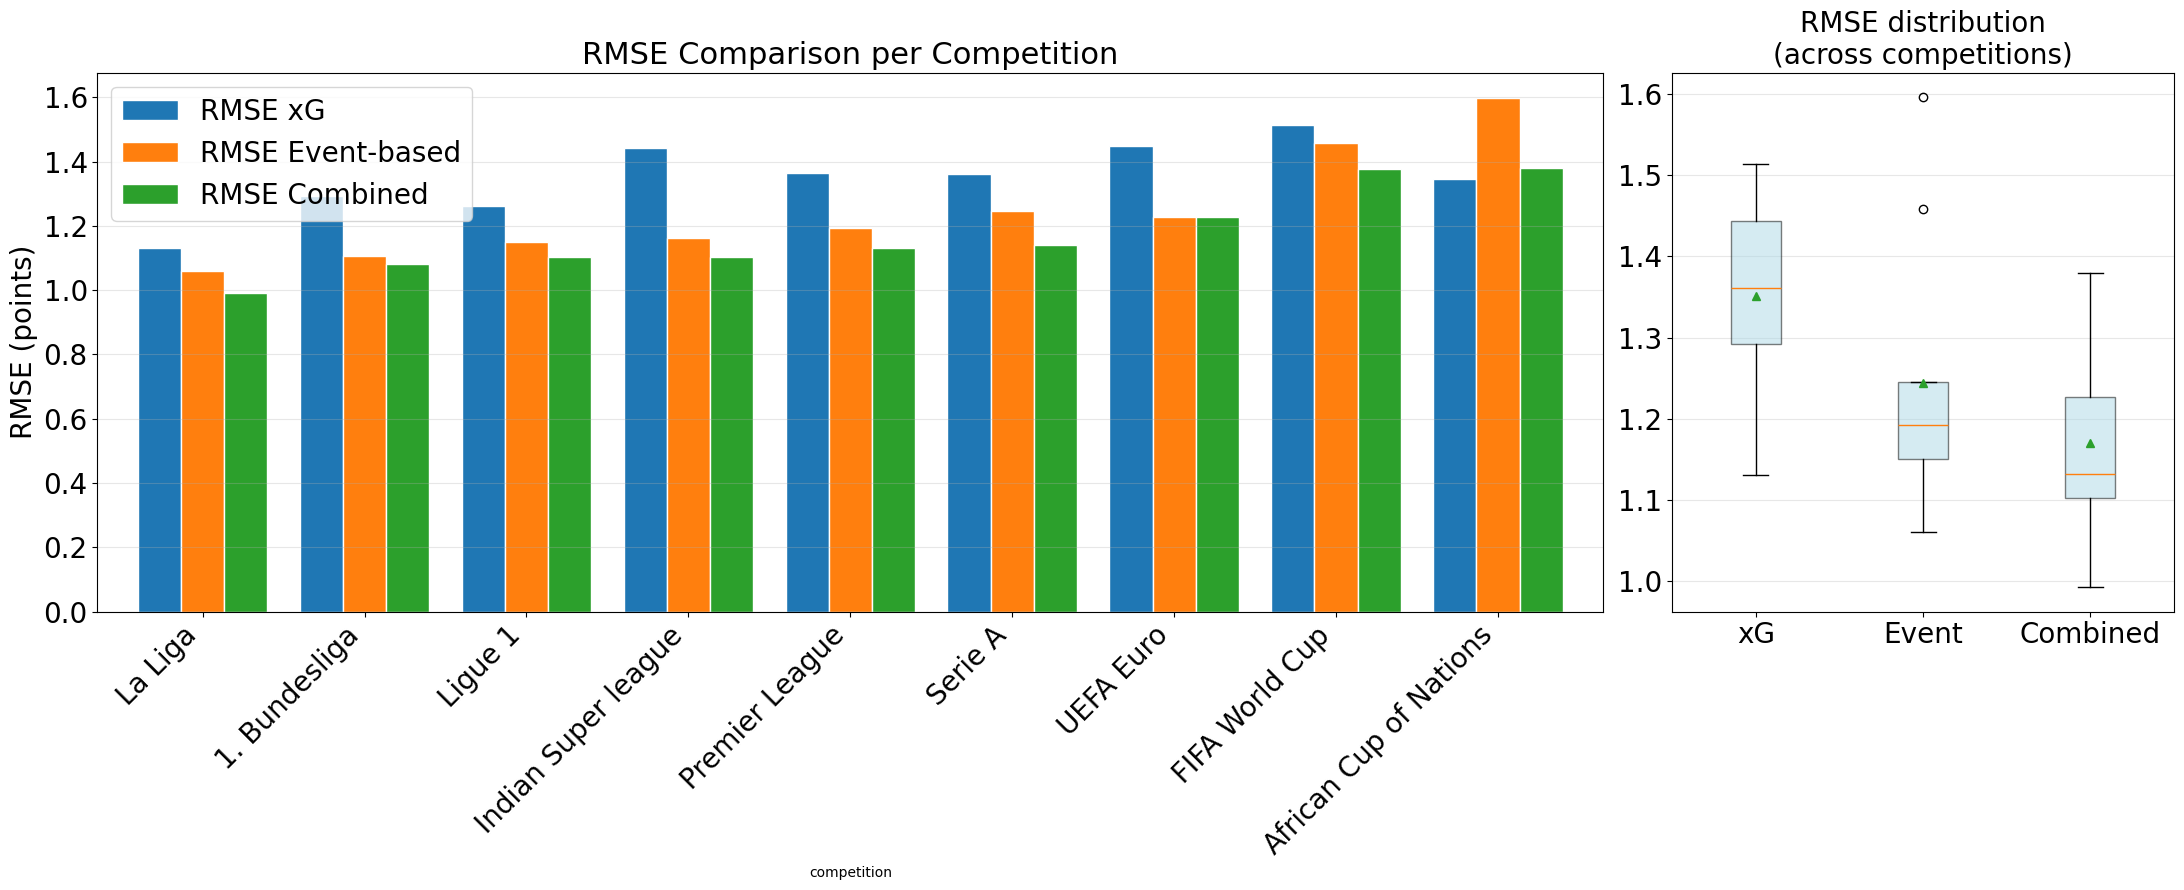

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import root_mean_squared_error

# ===============================
# Calcolo RMSE per competizione (stessa logica)
# ===============================
rows = []
min_matches = 50

for comp, g in df_team.groupby("competition_name"):
    if g["match_id"].nunique() < min_matches:
        continue
    rows.append({
        "competition": comp,
        "RMSE xG": root_mean_squared_error(g["real_points"], g["EP_xg"]),
        "RMSE Event-based": root_mean_squared_error(g["real_points"], g["xPts_events_eb"]),
        "RMSE Combined": root_mean_squared_error(g["real_points"], g["xPts_events"])
    })

rmse_comp = pd.DataFrame(rows).sort_values("RMSE Combined")

# ===============================
# Plot: Barplot (sx) + Boxplot (dx)
# ===============================
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(22, 9), 
    gridspec_kw={"width_ratios": [3, 1]}
)

# --- Sinistra: Barplot raggruppato ---
# Impostiamo 'competition' come indice per facilitare il plotting delle barre
rmse_plot_df = rmse_comp.set_index("competition")

rmse_plot_df.plot(
    kind='bar', 
    ax=ax1, 
    width=0.8, 
    edgecolor='white',
    # Puoi definire colori specifici se vuoi: color=['#1f77b4', '#ff7f0e', '#2ca02c']
)

ax1.set_xticklabels(rmse_plot_df.index, rotation=45, ha="right", fontsize=20)
ax1.set_ylabel("RMSE (points)", fontsize=20)
ax1.set_title("RMSE Comparison per Competition", fontsize=22)
ax1.legend(fontsize=20, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis="y", labelsize=20)

# --- Destra: Boxplot (stessa logica) ---
data = [
    rmse_comp["RMSE xG"].values,
    rmse_comp["RMSE Event-based"].values,
    rmse_comp["RMSE Combined"].values
]
ax2.boxplot(data, labels=["xG", "Event", "Combined"], showmeans=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.5))
ax2.set_title("RMSE distribution\n(across competitions)", fontsize=20)
ax2.tick_params(axis="x", labelsize=20)
ax2.tick_params(axis="y", labelsize=20)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig("rmse_competitions_barplot.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [29]:
# ===============================
# Tabella: RMSE / punti totali (%)
# ===============================
# punti totali reali per competizione
tot_points = (
    df_team.groupby("competition_name")["real_points"]
          .sum()
          .rename("TotalPoints")
          .reset_index()
)

# merge con RMSE per competizione
rmse_pct = rmse_comp.merge(tot_points, left_on="competition", right_on="competition_name", how="left")
rmse_pct.drop(columns=["competition_name"], inplace=True)

# percentuali
rmse_pct["RMSE_xG_%"]       = 100 * rmse_pct["RMSE_xG"]       / rmse_pct["TotalPoints"]
rmse_pct["RMSE_Event_%"]    = 100 * rmse_pct["RMSE_Event"]    / rmse_pct["TotalPoints"]
rmse_pct["RMSE_Combined_%"] = 100 * rmse_pct["RMSE_Combined"] / rmse_pct["TotalPoints"]

# tabella finale (puoi cambiare sort)
table_pct = (
    rmse_pct[["competition", "TotalPoints", "RMSE_xG_%", "RMSE_Event_%", "RMSE_Combined_%"]]
      .sort_values("RMSE_Combined_%")
)

print("\n=== RMSE / Total Points (%) by competition ===")
display(table_pct.style.format({
    "TotalPoints": "{:.0f}",
    "RMSE_xG_%": "{:.2f}",
    "RMSE_Event_%": "{:.2f}",
    "RMSE_Combined_%": "{:.2f}",
}))


KeyError: 'RMSE_xG'

In [ ]:
# ===========================================
# Competizioni per stagione con numero partite
# ===========================================

# Verifica colonne richieste
assert "season_name" in df_tm.columns
assert "competition_name" in df_tm.columns
assert "match_id" in df_tm.columns

# Raggruppamento
season_comp_counts = (
    df_tm
    .groupby(["season_name", "competition_name"])["match_id"]
    .nunique()                   # numero di match_id unici = partite
    .reset_index()
    .rename(columns={"match_id": "n_matches"})
    .sort_values(["season_name", "competition_name"])
)

# Stampa: elenco per stagione
for season in season_comp_counts["season_name"].unique():
    print(f"\n=== {season} ===")
    subset = season_comp_counts[season_comp_counts["season_name"] == season]
    for _, row in subset.iterrows():
        print(f"  - {row['competition_name']}: {row['n_matches']} partite")




=== 1958 ===
  - FIFA World Cup: 2 partite

=== 1962 ===
  - FIFA World Cup: 1 partite

=== 1970 ===
  - FIFA World Cup: 6 partite

=== 1970/1971 ===
  - Champions League: 1 partite

=== 1971/1972 ===
  - Champions League: 1 partite

=== 1972/1973 ===
  - Champions League: 1 partite

=== 1973/1974 ===
  - La Liga: 1 partite

=== 1974 ===
  - FIFA World Cup: 6 partite

=== 1977 ===
  - North American League: 1 partite

=== 1977/1978 ===
  - Copa del Rey: 1 partite

=== 1979 ===
  - FIFA U20 World Cup: 1 partite

=== 1981 ===
  - Liga Profesional: 1 partite

=== 1982/1983 ===
  - Copa del Rey: 1 partite

=== 1983/1984 ===
  - Copa del Rey: 1 partite

=== 1986 ===
  - FIFA World Cup: 3 partite

=== 1986/1987 ===
  - Serie A: 1 partite

=== 1988/1989 ===
  - UEFA Europa League: 3 partite

=== 1990 ===
  - FIFA World Cup: 1 partite

=== 1997/1998 ===
  - Liga Profesional: 1 partite

=== 1999/2000 ===
  - Champions League: 1 partite

=== 2003/2004 ===
  - Champions League: 1 partite
  - Pre

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ================================
# 1) Allinea i tipi di match_id
# ================================
df_xG["match_id"]    = df_xG["match_id"].astype(str)
df_merged["match_id"] = df_merged["match_id"].astype(str)

# ================================
# 2) Risultato REALE per match (prospettiva squadra in casa)
#    1 = vince team_A (casa)
#    0 = pareggio
#   -1 = vince team_B (trasferta)
# ================================
df_match_truth = df_xG[["match_id", "goals_A", "goals_B"]].copy()
df_match_truth["result_home"] = np.sign(
    df_match_truth["goals_A"] - df_match_truth["goals_B"]
).astype(int)

# ================================
# 3) Probabilità xG per match (già a livello match)
#    p_win  = P(vittoria casa)
#    p_draw = P(pareggio)
#    p_loss = P(vittoria trasferta)
# ================================
df_match_xg = df_xG[["match_id", "p_win", "p_draw", "p_loss"]].copy()

# Predizione discreta dal modello xG
df_match_xg["pred_xg_label"] = df_match_xg[["p_loss", "p_draw", "p_win"]].idxmax(axis=1)
mapping_xg = {"p_loss": -1, "p_draw": 0, "p_win": 1}
df_match_xg["pred_xg_result"] = df_match_xg["pred_xg_label"].map(mapping_xg).astype(int)

# ================================
# 4) Probabilità EVENT-BASED per match
#    Qui sfruttiamo direttamente df_merged, che ha una riga per match
#    con colonne *_home e *_away
# ================================

# prendo solo una riga per match (per sicurezza)
cols_ev = [
    "match_id",
    "p_win_mc", "p_draw_mc",
    "p_loss_mc"
]
df_ev_match = df_merged[cols_ev].drop_duplicates("match_id").copy()

# Definizione delle probabilità "vista da casa":
#   P(home win)  = prob che la squadra di casa vinca
#   P(away win)  = prob che la squadra in trasferta vinca
#   P(draw)      = media delle due stime di pareggio
df_ev_match["p_win_ev"]  = df_ev_match["p_win_mc"]          # P(casa vince)
df_ev_match["p_loss_ev"] = df_ev_match["p_loss_mc"]          # P(trasferta vince)
df_ev_match["p_draw_ev"] = 0.5 * (
    df_ev_match["p_draw_mc"]
)

# Predizione discreta event-based (home perspective)
df_ev_match["pred_event_label"] = df_ev_match[
    ["p_loss_ev", "p_draw_ev", "p_win_ev"]
].idxmax(axis=1)

mapping_ev = {"p_loss_ev": -1, "p_draw_ev": 0, "p_win_ev": 1}
df_ev_match["pred_event_result"] = df_ev_match[
    "pred_event_label"
].map(mapping_ev).astype(int)

# ================================
# 5) Merge di TUTTO a livello match
# ================================
df_match_all = (
    df_match_truth[["match_id", "result_home"]]
    .merge(df_match_xg[["match_id", "pred_xg_result"]], on="match_id", how="inner")
    .merge(df_ev_match[["match_id", "pred_event_result"]], on="match_id", how="inner")
)

print("Numero di partite usate:", df_match_all.shape[0])
display(df_match_all.head())

# ================================
# 6) Metriche a livello MATCH
# ================================
y_true  = df_match_all["result_home"].astype(int)       # 1=home win, 0=draw, -1=away win
y_xg    = df_match_all["pred_xg_result"].astype(int)    # predizione modello xG
y_event = df_match_all["pred_event_result"].astype(int) # predizione modello event-based

print("\n=== ACCURACY (match-level, home perspective) ===")
print(f"xG-based:    {accuracy_score(y_true, y_xg):.3f}")
print(f"Event-based: {accuracy_score(y_true, y_event):.3f}")

print("\n=== F1 MACRO (match-level) ===")
print(f"xG-based:    {f1_score(y_true, y_xg, average='macro'):.3f}")
print(f"Event-based: {f1_score(y_true, y_event, average='macro'):.3f}")

labels = [-1, 0, 1]

print("\n=== CONFUSION MATRIX – xG-based (rows=true, cols=pred; order=[-1,0,1]) ===")
print(confusion_matrix(y_true, y_xg, labels=labels))

print("\n=== CONFUSION MATRIX – Event-based (rows=true, cols=pred; order=[-1,0,1]) ===")
print(confusion_matrix(y_true, y_event, labels=labels))

print("\n=== CLASSIFICATION REPORT – xG-based ===")
print(classification_report(y_true, y_xg, labels=labels))

print("\n=== CLASSIFICATION REPORT – Event-based ===")
print(classification_report(y_true, y_event, labels=labels))


Numero di partite usate: 2958


,match_id,result_home,pred_xg_result,pred_event_result
0,7430,1,1,1
1,7443,1,-1,1
2,7444,0,-1,-1
3,7445,1,0,1
4,7451,1,1,1



=== ACCURACY (match-level, home perspective) ===
xG-based:    0.626
Event-based: 0.678

=== F1 MACRO (match-level) ===
xG-based:    0.556
Event-based: 0.580

=== CONFUSION MATRIX – xG-based (rows=true, cols=pred; order=[-1,0,1]) ===
[[ 636  110  183]
 [ 239  150  318]
 [ 141  115 1066]]

=== CONFUSION MATRIX – Event-based (rows=true, cols=pred; order=[-1,0,1]) ===
[[ 731   79  119]
 [ 278  106  323]
 [  95   57 1170]]

=== CLASSIFICATION REPORT – xG-based ===
              precision    recall  f1-score   support

          -1       0.63      0.68      0.65       929
           0       0.40      0.21      0.28       707
           1       0.68      0.81      0.74      1322

    accuracy                           0.63      2958
   macro avg       0.57      0.57      0.56      2958
weighted avg       0.60      0.63      0.60      2958


=== CLASSIFICATION REPORT – Event-based ===
              precision    recall  f1-score   support

          -1       0.66      0.79      0.72       929
